### Multivariate Gaussian anomaly detection — recipe

Given (d) features:

1. **Estimate the Gaussian**
   $
   \mu,\quad \Sigma
   $

$\Sigma$ is the covariance matrix, which is symmetric and positive definite.

The values of the diagonal of $\Sigma$ are the variances of each feature, and the off-diagonal values are the covariances between features.

2. **For a new point (x), calculate Mahalanobis distance**
   $
   D^2=(x-\mu)^T\Sigma^{-1}(x-\mu)
   $

3. **Under the Gaussian assumption**
   $
   D^2\sim\chi^2_d
   $

4. **Choose your desired false-positive rate** $(\alpha)$, e.g. (1%).

5. **Set the anomaly threshold**
   $   \tau=\chi^2_{d,,1-\alpha}   $

6. **Classify**
   $
   \boxed{
   D^2>\tau\quad\Rightarrow\quad\text{anomaly}
   }
   $

### Example: 10 dimensions, 1% threshold

$
d=10,\qquad \alpha=0.01
$

$
\tau=\chi^2_{10,0.99} \approx23.21
$

so

$\boxed{D^2>23.21}$

or equivalently

$\boxed{D>4.82}$

**Important:** this is **not** "any feature (>4.82\sigma)." It is the **joint Mahalanobis distance** of the entire 10-dimensional observation.


In [9]:
# function that returns chi-squared critical value for a given significance level and degrees of freedom
def chi_squared_critical_value(alpha, df):
    from scipy.stats import chi2
    return chi2.ppf(1 - alpha, df)

chi_squared_critical_value(0.001, 10) # the equivalent formula in Excel is =CHISQ.INV.RT(0.01, 10)

np.float64(29.58829844507442)

Estimated mean:
[10.1139643  20.09955843]

Estimated covariance:
[[4.1205694  0.01513261]
 [0.01513261 8.32212899]]

Mahalanobis distance² = 13.712
Mahalanobis distance  = 3.703

Chi² threshold = 9.210
ANOMALY


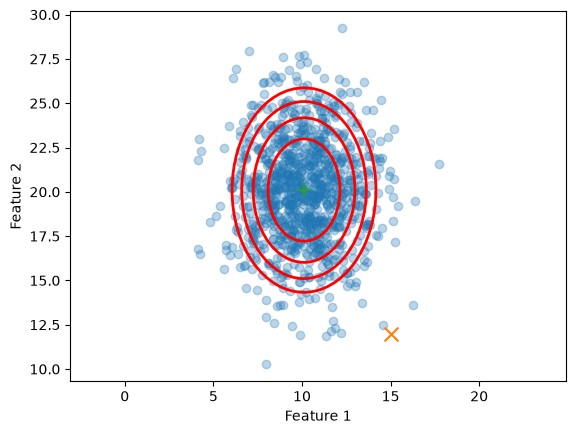

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from matplotlib.patches import Ellipse

def plot_mahalanobis_contours(mu, Sigma, ax=None):
    if ax is None:
        ax = plt.gca()
    for k in range(1, 5):
        vals, vecs = np.linalg.eigh(Sigma)
        order = vals.argsort()[::-1]
        vals = vals[order]
        vecs = vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals * k)
        ellip = Ellipse(xy=mu, width=width, height=height, angle=theta, edgecolor='r', fc='None', lw=2)
        ax.add_patch(ellip)
# --------------------------------------------------
# 1. Generate random Gaussian training data
# --------------------------------------------------

np.random.seed(42)

mu_true = np.array([10, 20])

Sigma_true = np.array([
    [4, 0],
    [0, 9]
])

X = np.random.multivariate_normal(
    mean=mu_true,
    cov=Sigma_true,
    size=1000
)

# --------------------------------------------------
# 2. Estimate mean and covariance from the data
# --------------------------------------------------

mu = X.mean(axis=0)
Sigma = np.cov(X, rowvar=False)

print("Estimated mean:")
print(mu)

print("\nEstimated covariance:")
print(Sigma)

# --------------------------------------------------
# 3. Generate a new observation
# --------------------------------------------------

x = np.array([15, 12])

# --------------------------------------------------
# 4. Calculate Mahalanobis distance
# --------------------------------------------------

delta = x - mu

D2 = delta.T @ np.linalg.solve(Sigma, delta)
D = np.sqrt(D2)

print(f"\nMahalanobis distance² = {D2:.3f}")
print(f"Mahalanobis distance  = {D:.3f}")

# --------------------------------------------------
# 5. Choose 1% anomaly threshold
# --------------------------------------------------

alpha = 0.01
d = X.shape[1]

threshold = chi2.ppf(1 - alpha, df=d)

print(f"\nChi² threshold = {threshold:.3f}")

if D2 > threshold:
    print("ANOMALY")
else:
    print("NORMAL")

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------

plt.scatter(X[:, 0], X[:, 1], alpha=0.3)

plt.scatter(
    x[0], x[1],
    s=100,
    marker='x'
)

plt.scatter(
    mu[0], mu[1],
    s=100,
    marker='+'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plot_mahalanobis_contours(mu, Sigma, ax=plt.gca())
plt.show()

In [8]:
normal = np.array([11, 22])
anomaly = np.array([18, 35])

for name, x in [("Normal", normal), ("Anomaly", anomaly)]:

    delta = x - mu
    D2 = delta.T @ np.linalg.solve(Sigma, delta)

    print(
        f"{name:8s}: "
        f"D² = {D2:6.2f}, "
        f"D = {np.sqrt(D2):5.2f}, "
        f"{'ANOMALY' if D2 > threshold else 'NORMAL'}"
    )

Normal  : D² =   0.62, D =  0.79, NORMAL
Anomaly : D² =  41.67, D =  6.46, ANOMALY
